# 9 &middot; Contact: Dropping an Elastic Block on the Floor

Inertia + gravity + contact together: an elastic block is **dropped** onto a flat
floor and bounces. We step it with Backward Euler and watch the three energies
trade off &mdash; gravity builds **kinetic** energy on the way down; impact spikes
the **contact** penalty and stores **elastic** energy; the rebound reverses it.

In [1]:
# --- make the *local* simkit (this repo) importable, ahead of any installed copy ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import simkit
import simkit.energies as energies
from simkit.integrators import backward_euler
import utils
os.makedirs("media", exist_ok=True)

## Block, floor, and a Backward-Euler step

`contact_springs_plane_energy(X, k, p, n, M)` penalizes any vertex below the
plane through `p` with upward normal `n`.

In [2]:
X, T = utils.triangulated_grid(nx=10, ny=8, width=0.5, height=0.5)
X[:, 1] += 1.0                                       # start up high
n, dim = X.shape
J, vol = simkit.deformation_jacobian(X, T), simkit.volume(X, T)
M_n = simkit.massmatrix(X, T, rho=1e3)
M   = sp.sparse.kron(M_n, sp.sparse.eye(dim)).tocsc()
f_g = simkit.gravity_force(X, T, a=-9.8, rho=1e3).reshape(-1, 1)
mu, lam = simkit.ympr_to_lame(1e5, 0.4)
mu  = np.full((len(T), 1), mu)
lam = np.full((len(T), 1), lam)

FLOOR_Y = -0.6
floor_p, floor_n = np.array([0.0, FLOOR_Y]), np.array([0.0, 1.0])
K_FLOOR, h = 1e5, 0.01

def be_step(U, U_prev):
    # potential only -- backward_euler adds the inertial term and Newton-solves
    def energy(x):
        xn, xc = x.reshape(-1, dim), x.reshape(-1, 1)
        E_elastic = energies.macklin_mueller_neo_hookean_energy_x(xn, J, mu, lam, vol)
        E_floor   = energies.contact_springs_plane_energy(xn, K_FLOOR, floor_p, floor_n, M=M_n)
        E_gravity = -(f_g.T @ xc)[0, 0]
        return E_elastic + E_floor + E_gravity
    def gradient(x):
        xn, xc = x.reshape(-1, dim), x.reshape(-1, 1)
        g_elastic = energies.macklin_mueller_neo_hookean_gradient_x(xn, J, mu, lam, vol)
        g_floor   = energies.contact_springs_plane_gradient(xn, K_FLOOR, floor_p, floor_n, M=M_n)
        g_gravity = -f_g
        return g_elastic + g_floor + g_gravity
    def hessian(x):
        xn = x.reshape(-1, dim)
        H_elastic = energies.macklin_mueller_neo_hookean_hessian_x(xn, J, mu, lam, vol, psd=True)
        H_floor   = energies.contact_springs_plane_hessian(xn, K_FLOOR, floor_p, floor_n, M=M_n)
        return H_elastic + H_floor
    x = backward_euler(U.reshape(-1, 1), U_prev.reshape(-1, 1),
                       energy, gradient, hessian, M, h, max_iter=8, do_line_search=True)
    return x.reshape(n, dim)

## Run the drop, recording elastic / kinetic / contact energy each step

impact near t = 0.55s


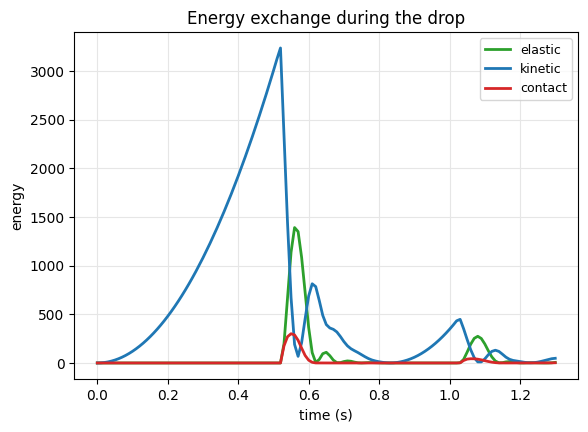

In [3]:
U, U_prev = X.copy(), X.copy()
states, t_axis = [U.copy()], [0.0]
E_el, E_kin, E_con = [0.0], [0.0], [0.0]
for s in range(130):
    U_next = be_step(U, U_prev)
    v = ((U_next - U) / h).flatten()
    E_el.append(energies.macklin_mueller_neo_hookean_energy_x(U_next, J, mu, lam, vol))
    E_kin.append(0.5 * float(v @ (M @ v)))
    E_con.append(energies.contact_springs_plane_energy(U_next, K_FLOOR, floor_p, floor_n, M=M_n))
    U_prev, U = U, U_next
    states.append(U.copy()); t_axis.append((s + 1) * h)

t_axis = np.array(t_axis)
series = {"elastic": np.array(E_el), "kinetic": np.array(E_kin), "contact": np.array(E_con)}
print(f"impact near t = {t_axis[int(np.argmax(E_con))]:.2f}s")

utils.line_plot(t_axis, series, xlabel="time (s)", ylabel="energy",
                colors=utils.ENERGY_COLORS, title="Energy exchange during the drop")
plt.show()


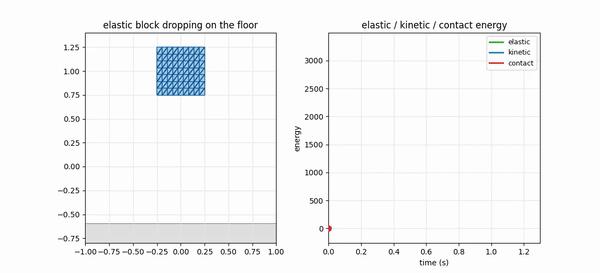

In [4]:
fig, anim = utils.animate_dynamics(states, T, t_axis, series, lims=((-1.0, 1.0), (-0.8, 1.4)),
    xlabel="time (s)", ylabel="energy", colors=utils.ENERGY_COLORS, floor_y=FLOOR_Y,
    scene_title="elastic block dropping on the floor",
    title="elastic / kinetic / contact energy", fps=25)
utils.save_anim(anim, "media/09_contact_plane.mp4", fps=25)
plt.close(fig)
utils.show_anim(anim)

### Takeaways
* Gravity &rarr; **kinetic** on the way down; impact &rarr; **elastic** +
  **contact**; rebound reverses it.
* The **contact** penalty spikes exactly at impact.
* Penalty contact + Backward Euler lose a little energy each bounce (the spring is
  springy, BE damps), so the block doesn't bounce back to full height.